<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/05_Hernandez_Alvaro_ImplementacionRNR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Implementación de Redes Neuronales Recurrentes**

* Asignatura: Redes Neuronales Profundas
* Profesor: Dr. José David Díaz Román
* Alumno: **Álvaro Hernández Jarquín**
* Matrícula: 263150
* 10 de marzo de 2026




En archivo comprimido compartido contiene una base de datos de precios de acciones de distintas empresas (un archivo para cada empresa). La información de cada archivo está estructurada de la siguiente manera:

$$
\begin{array}{|c|c|c|c|c|c|c|}
\hline
\text{Date} & \text{Open} & \text{High} & \text{Low} & \text{Close} & \text{Volume} & \text{Name} \\
\hline
1/3/2006 & 47.47 & 47.85 & 46.25 & 47.58 & 7582127 & \text{AMZN} \\
\hline
1/4/2006 & 47.48 & 47.73 & 46.69 & 47.25 & 7440914 & \text{AMZN} \\
\hline
1/5/2006 & 47.16 & 48.2 & 47.11 & 47.65 & 5417258 & \text{AMZN} \\
\hline
1/6/2006 & 47.97 & 48.58 & 47.32 & 47.87 & 6154285 & \text{AMZN} \\
\hline
... & ... & ... & ... & ... & ... & ... \\
\hline
... & ... & ... & ... & ... & ... & ... \\
\hline
\end{array}
$$

El objetivo de este ejercicio es implementar una red neuronal recurrente para predecir el valor más bajo de una acción (columna **Low**) tomando como referencia un historial de valores de días previos. Cada estudiante puede elegir libremente el archivo de la empresa con la que trabajará.


# **Instrucciones**

1. División del conjunto de datos
* Use los datos desde el inicio hasta el año 2016 como conjunto de entrenamiento.
* Use los datos del año 2017 en adelante como conjunto de prueba.

2. Implementación del modelo
* Se proporciona un archivo base de programación que les permitirá:
  * Leer los archivos de datos.
  * Construir los conjuntos de entrenamiento y prueba.
  * Definir y entrenar una red neuronal recurrente.

3. Pruebas a realizar
* Entrene y evalúe un modelo usando celdas LSTM.
* Entrene y evalúe un modelo usando celdas GRU.
* En ambos casos, realice las pruebas considerando:
    * Un historial de 30 días previos.
    * Un historial de 50 días previos.

4. Resultados a reportar
* Registre las curvas comparativas entre los valores esperados y los valores predichos por cada modelo.
* Calcule y reporte el valor de RMSE (Root Mean Square Error) para cada prueba.
* Compare y discuta los resultados obtenidos entre:
    * Modelos con LSTM vs GRU.
    * Uso de 30 días vs 50 días de historial.


In [8]:
# Importando las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Input
import math

In [2]:
# Cargar los datos
path_file = "/content/drive/MyDrive/ClassFiles/DataSets/AMZN_2006-01-01_to_2018-01-01.csv"
dataset1 = pd.read_csv(path_file, index_col='Date', parse_dates=['Date'])
dataset1.head()

dataset = dataset1.dropna()  # Eliminar cualquier fila con NaN en cualquier columna

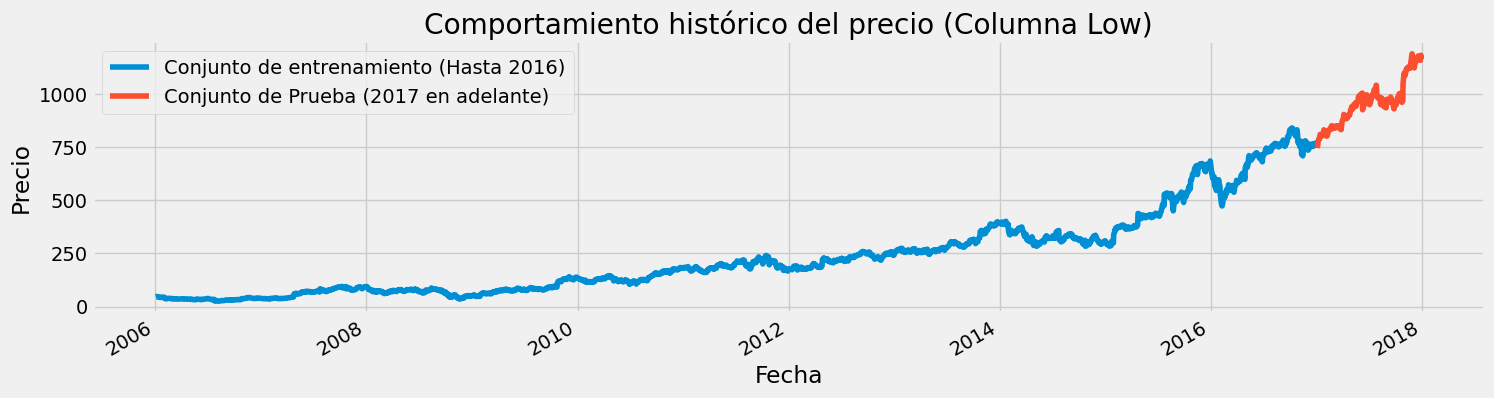

In [4]:
# Visualización exploratoria de los datos históricos
plt.figure(figsize=(16,4))
dataset["Low"][:'2016'].plot(legend=True)
dataset["Low"]['2017':].plot(legend=True)
plt.legend(['Conjunto de entrenamiento (Hasta 2016)', 'Conjunto de Prueba (2017 en adelante)'])
plt.title('Comportamiento histórico del precio (Columna Low)')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.show()

## Ejercicio para Amazon (AMZN) - LSTM 30 días

In [3]:
# Parámetros de esta prueba
previous_days = 30
model_type = 'LSTM'

# División del conjunto de datos
target_col = "Low"
training_set = dataset.loc[:'2016', [target_col]].values
test_set = dataset.loc['2017':, [target_col]].values

In [5]:
# Escalar los datos de entrenamiento
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

# Crear la estructura de datos con los 'previous_days'
X_train = []
y_train = []
N = training_set.shape[0]

for i in range(previous_days, N):
    X_train.append(training_set_scaled[i-previous_days:i, 0])
    y_train.append(training_set_scaled[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

In [6]:
# Reshaping X_train para que tenga la forma esperada por RNN [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [9]:
# Construcción de la Arquitectura de la Red Neuronal
regressor = Sequential()

regressor.add(Input(shape=(X_train.shape[1],1)))
regressor.add(LSTM(50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))

# Capa de salida
regressor.add(Dense(units=1, activation='linear'))

# Compilación
regressor.compile(optimizer='rmsprop', loss='mean_squared_error')
regressor.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Entrenamiento
print(f"Entrenando modelo {model_type} con {previous_days} días de historial...")
regressor.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)


Entrenando modelo LSTM con 30 días de historial...
Epoch 1/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 0.0069
Epoch 2/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 0.0037
Epoch 3/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0032
Epoch 4/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0029
Epoch 5/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0025
Epoch 6/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0023
Epoch 7/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0021
Epoch 8/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.0016
Epoch 9/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0020
Epoch 10/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0017
Epoch 11/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.0016
Epoch 12/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0017
Epoch 13/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0016
Epoch 14/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0014
Epoch 15/50
86/86 ━━

In [11]:
# Preparar los datos de prueba y hacer predicciones
# Unimos los datos reales (columna Low) para tener el contexto de los días previos al 2017
dataset_total = pd.concat((dataset[target_col][:'2016'], dataset[target_col]['2017':]), axis=0)
inputs = dataset_total[len(dataset_total) - len(test_set) - previous_days:].values
inputs = inputs.reshape(-1,1)
inputs  = sc.transform(inputs)

X_test = []
N1 = inputs.shape[0]
for i in range(previous_days, N1):
    X_test.append(inputs[i-previous_days:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [12]:
# Predicción y transformación inversa a valores reales
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step


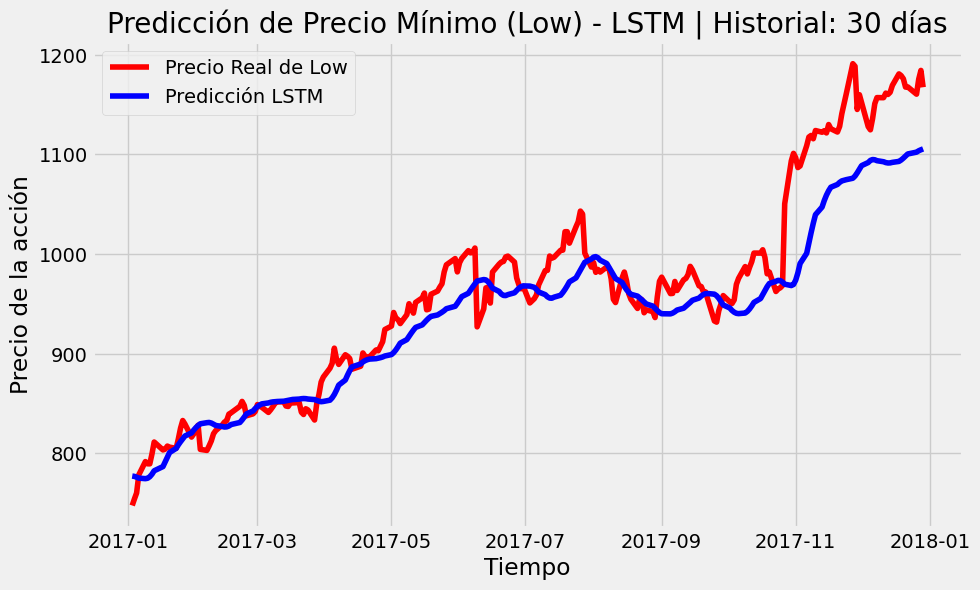

El valor RMSE para LSTM (30 días) es: 40.21


In [13]:
# Visualizamos
plt.figure(figsize=(10,6))
plt.plot(dataset.index[-len(test_set):], test_set, color='red', label=f'Precio Real de {target_col}')
plt.plot(dataset.index[-len(test_set):], predicted_stock_price, color='blue', label=f'Predicción {model_type}')
plt.title(f'Predicción de Precio Mínimo (Low) - {model_type} | Historial: {previous_days} días')
plt.xlabel('Tiempo')
plt.ylabel('Precio de la acción')
plt.legend()
plt.show()

# Evaluación
rmse = math.sqrt(mean_squared_error(test_set, predicted_stock_price))
print(f"El valor RMSE para {model_type} ({previous_days} días) es: {rmse:.2f}")

## Ejercicio para Amazon (AMZN) LSTM 50 días

In [14]:
# Parámetros de esta prueba
previous_days = 50
model_type = 'LSTM'

# División del conjunto de datos
target_col = "Low"
training_set = dataset.loc[:'2016', [target_col]].values
test_set = dataset.loc['2017':, [target_col]].values

In [15]:
# Escalar los datos de entrenamiento
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

# Crear la estructura de datos con los 'previous_days'
X_train = []
y_train = []
N = training_set.shape[0]

for i in range(previous_days, N):
    X_train.append(training_set_scaled[i-previous_days:i, 0])
    y_train.append(training_set_scaled[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

In [16]:
# Reshaping X_train para que tenga la forma esperada por RNN [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [17]:
# Construcción de la Arquitectura de la Red Neuronal
regressor = Sequential()

regressor.add(Input(shape=(X_train.shape[1],1)))
regressor.add(LSTM(50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))

# Capa de salida
regressor.add(Dense(units=1, activation='linear'))

# Compilación
regressor.compile(optimizer='rmsprop', loss='mean_squared_error')
regressor.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 50, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 50, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Entrenamiento
print(f"Entrenando modelo {model_type} con {previous_days} días de historial...")
regressor.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)


Entrenando modelo LSTM con 50 días de historial...
Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - loss: 0.0090
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 0.0043
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0034
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0025
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0023
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - loss: 0.0023
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 0.0021
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.0020
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0019
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - loss: 0.0017
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.0017
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 0.0017
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 0.0017
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - loss: 0.0015
Epoch 15/50
85/85 ━

In [19]:
# Preparar los datos de prueba y hacer predicciones
# Unimos los datos reales (columna Low) para tener el contexto de los días previos al 2017
dataset_total = pd.concat((dataset[target_col][:'2016'], dataset[target_col]['2017':]), axis=0)
inputs = dataset_total[len(dataset_total) - len(test_set) - previous_days:].values
inputs = inputs.reshape(-1,1)
inputs  = sc.transform(inputs)

X_test = []
N1 = inputs.shape[0]
for i in range(previous_days, N1):
    X_test.append(inputs[i-previous_days:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [20]:
# Predicción y transformación inversa a valores reales
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step


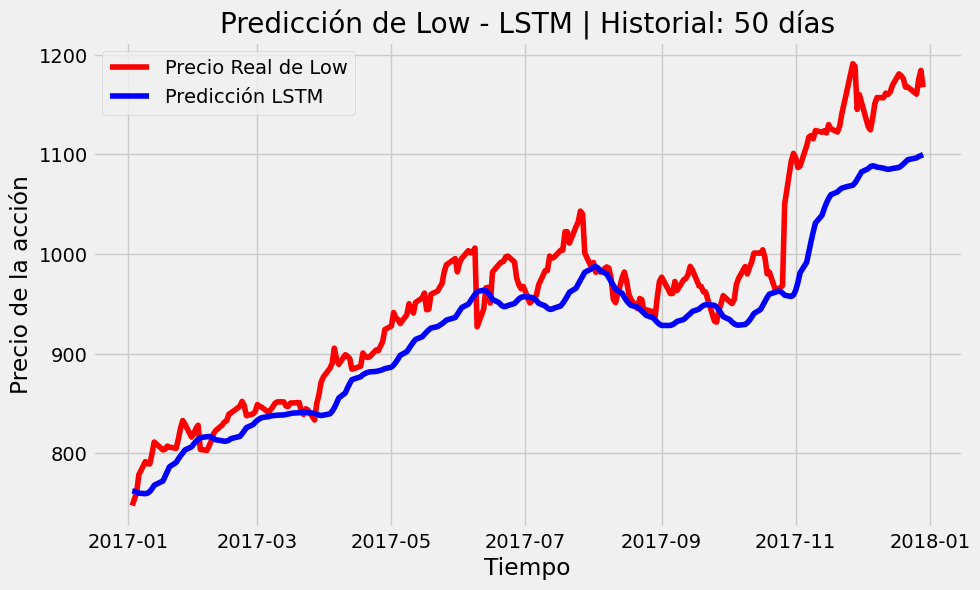

El valor RMSE para LSTM (50 días) es: 46.73


In [21]:
# Visualizamos
plt.figure(figsize=(10,6))
plt.plot(dataset.index[-len(test_set):],
         test_set.flatten(),
         color='red',
         label=f'Precio Real de {target_col}')

plt.plot(dataset.index[-len(test_set):],
         predicted_stock_price.flatten(),
         color='blue',
         label=f'Predicción {model_type}')

plt.title(f'Predicción de Low - {model_type} | Historial: {previous_days} días')
plt.xlabel('Tiempo')
plt.ylabel('Precio de la acción')
plt.legend()
plt.show()

# Evaluación
rmse = math.sqrt(mean_squared_error(test_set, predicted_stock_price))
print(f"El valor RMSE para {model_type} ({previous_days} días) es: {rmse:.2f}")

## Ejercicio para Amazon (AMZN) GRU 30 días

In [22]:
# Parámetros de esta prueba
previous_days = 30
model_type = 'GRU'

# División del conjunto de datos
target_col = "Low"
training_set = dataset.loc[:'2016', [target_col]].values
test_set = dataset.loc['2017':, [target_col]].values

In [23]:
# Escalar los datos de entrenamiento
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

# Crear la estructura de datos con los 'previous_days'
X_train = []
y_train = []
N = training_set.shape[0]

for i in range(previous_days, N):
    X_train.append(training_set_scaled[i-previous_days:i, 0])
    y_train.append(training_set_scaled[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

In [24]:
# Reshaping X_train para que tenga la forma esperada por RNN [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [25]:
# Construcción de la Arquitectura de la Red Neuronal
regressor = Sequential()

regressor.add(Input(shape=(X_train.shape[1],1)))
regressor.add(GRU(50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(GRU(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(GRU(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(GRU(units=50))
regressor.add(Dropout(0.2))

# Capa de salida
regressor.add(Dense(units=1, activation='linear'))

# Compilación
regressor.compile(optimizer='rmsprop', loss='mean_squared_error')
regressor.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 50)         │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 30, 50)         │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 30, 50)         │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,901 (210.55 KB)

 Trainable params: 53,901 (210.55 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Entrenamiento
print(f"Entrenando modelo {model_type} con {previous_days} días de historial...")
regressor.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)


Entrenando modelo GRU con 30 días de historial...
Epoch 1/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - loss: 0.0077
Epoch 2/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0036
Epoch 3/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0028
Epoch 4/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0026
Epoch 5/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0025
Epoch 6/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.0021
Epoch 7/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.0020
Epoch 8/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0019
Epoch 9/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0020
Epoch 10/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0020
Epoch 11/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0019
Epoch 12/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - loss: 0.0019
Epoch 13/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0018
Epoch 14/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0017
Epoch 15/50
86/86 ━━━

In [27]:
# Preparar los datos de prueba y hacer predicciones
# Unimos los datos reales (columna Low) para tener el contexto de los días previos al 2017
dataset_total = pd.concat((dataset[target_col][:'2016'], dataset[target_col]['2017':]), axis=0)
inputs = dataset_total[len(dataset_total) - len(test_set) - previous_days:].values
inputs = inputs.reshape(-1,1)
inputs  = sc.transform(inputs)

X_test = []
N1 = inputs.shape[0]
for i in range(previous_days, N1):
    X_test.append(inputs[i-previous_days:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [28]:
# Predicción y transformación inversa a valores reales
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step


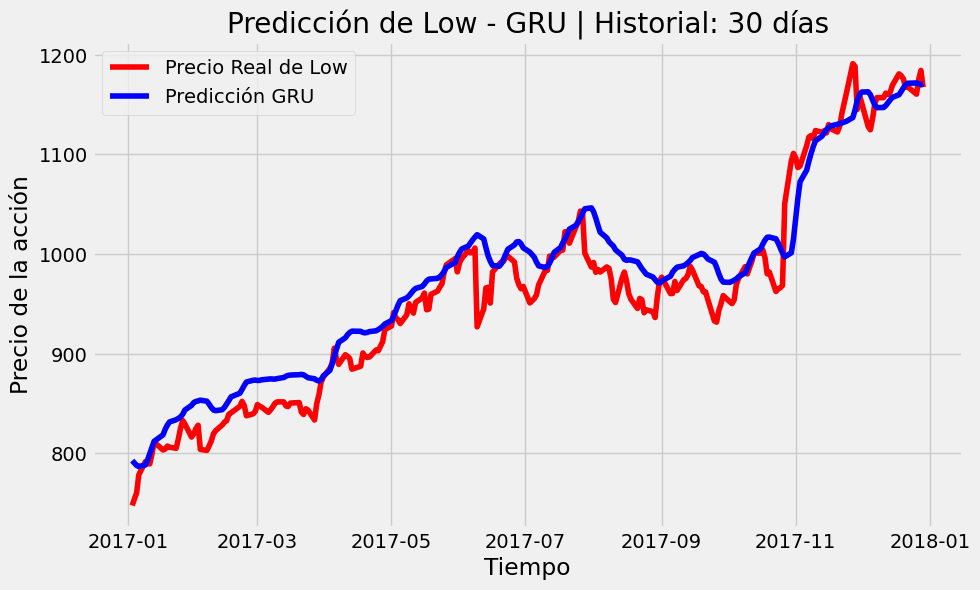

El valor RMSE para GRU (30 días) es: 27.58


In [29]:
# Visualizamos
plt.figure(figsize=(10,6))
plt.plot(dataset.index[-len(test_set):],
         test_set.flatten(),
         color='red',
         label=f'Precio Real de {target_col}')

plt.plot(dataset.index[-len(test_set):],
         predicted_stock_price.flatten(),
         color='blue',
         label=f'Predicción {model_type}')

plt.title(f'Predicción de Low - {model_type} | Historial: {previous_days} días')
plt.xlabel('Tiempo')
plt.ylabel('Precio de la acción')
plt.legend()
plt.show()

# Evaluación
rmse = math.sqrt(mean_squared_error(test_set, predicted_stock_price))
print(f"El valor RMSE para {model_type} ({previous_days} días) es: {rmse:.2f}")

## Ejercicio para Amazon (AMZN) GRU 50 días

In [30]:
# Parámetros de esta prueba
previous_days = 50
model_type = 'GRU'

# División del conjunto de datos
target_col = "Low"
training_set = dataset.loc[:'2016', [target_col]].values
test_set = dataset.loc['2017':, [target_col]].values

In [31]:
# Escalar los datos de entrenamiento
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

# Crear la estructura de datos con los 'previous_days'
X_train = []
y_train = []
N = training_set.shape[0]

for i in range(previous_days, N):
    X_train.append(training_set_scaled[i-previous_days:i, 0])
    y_train.append(training_set_scaled[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

In [32]:
# Reshaping X_train para que tenga la forma esperada por RNN [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [33]:
# Construcción de la Arquitectura de la Red Neuronal
regressor = Sequential()

regressor.add(Input(shape=(X_train.shape[1],1)))
regressor.add(GRU(50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(GRU(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(GRU(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(GRU(units=50))
regressor.add(Dropout(0.2))

# Capa de salida
regressor.add(Dense(units=1, activation='linear'))

# Compilación
regressor.compile(optimizer='rmsprop', loss='mean_squared_error')
regressor.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 50, 50)         │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 50, 50)         │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ (None, 50, 50)         │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,901 (210.55 KB)

 Trainable params: 53,901 (210.55 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Entrenamiento
print(f"Entrenando modelo {model_type} con {previous_days} días de historial...")
regressor.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)


Entrenando modelo GRU con 50 días de historial...
Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - loss: 0.0080
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - loss: 0.0034
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0029
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0024
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0025
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - loss: 0.0023
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - loss: 0.0021
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - loss: 0.0021
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - loss: 0.0020
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - loss: 0.0017
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - loss: 0.0017
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - loss: 0.0018
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - loss: 0.0017
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0017
Epoch 15/50
8

In [35]:
# Preparar los datos de prueba y hacer predicciones
# Unimos los datos reales (columna Low) para tener el contexto de los días previos al 2017
dataset_total = pd.concat((dataset[target_col][:'2016'], dataset[target_col]['2017':]), axis=0)
inputs = dataset_total[len(dataset_total) - len(test_set) - previous_days:].values
inputs = inputs.reshape(-1,1)
inputs  = sc.transform(inputs)

X_test = []
N1 = inputs.shape[0]
for i in range(previous_days, N1):
    X_test.append(inputs[i-previous_days:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [36]:
# Predicción y transformación inversa a valores reales
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step


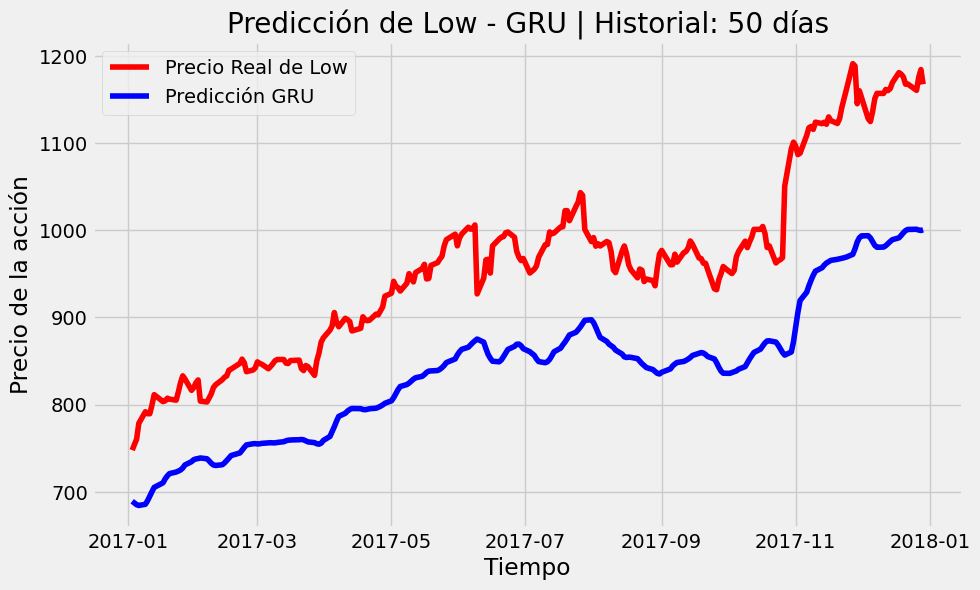

El valor RMSE para GRU (50 días) es: 125.08


In [37]:
# Visualizamos
plt.figure(figsize=(10,6))
plt.plot(dataset.index[-len(test_set):],
         test_set.flatten(),
         color='red',
         label=f'Precio Real de {target_col}')

plt.plot(dataset.index[-len(test_set):],
         predicted_stock_price.flatten(),
         color='blue',
         label=f'Predicción {model_type}')

plt.title(f'Predicción de Low - {model_type} | Historial: {previous_days} días')
plt.xlabel('Tiempo')
plt.ylabel('Precio de la acción')
plt.legend()
plt.show()

# Evaluación
rmse = math.sqrt(mean_squared_error(test_set, predicted_stock_price))
print(f"El valor RMSE para {model_type} ({previous_days} días) es: {rmse:.2f}")

$$
\begin{array}{|c|c|c|c|}
\hline
\text{Modelo} & \text{30 días} & \text{50 días} \\
\hline
\text{LSTM} & 40.21 & 46.73 \\
\hline
\text{GRU} & 27.58 & 125.08 \\
\hline
\end{array}
$$

**Conclusiones**:<br>
Al evaluar los dos modelos con diferente historial de días, GRU demostró ser mejor modelo que LSTM ya que logró el RMSE más bajo de todos, con 27.58. Esto lo logró con una intervalo de 30 días, por lo que su arquitectura es suficiente para evitar el sobreajuste. LSTM no varía tanto al usar 30 y 50 días, lo que lo hace más estable cuando se aumenta el historial. Inferimos que esto se debe a que maneja mejor el ruido.
Cuando aumentamos el tiempo de 30 a 50 días los dos modelos disminuyen su rendimiento.
Es notable que GRU, al aumentar 20 días, hace aumentar mucho su error. Es posible que se sobreajustó.
